In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import cupy as cp

### Krok 1 - Laplasjany

In [5]:
def laplacian_np(Z):
    lap_np = np.roll(Z, 1, 0) + np.roll(Z, -1, 0) + np.roll(Z, 1, 1) + np.roll(Z, -1, 1) - 4 * Z
    return lap_np

def laplacian_cp(Z):
    lap_cp = cp.roll(Z, 1, 0) + cp.roll(Z, -1, 0) + cp.roll(Z, 1, 1) + cp.roll(Z, -1, 1) - 4 * Z
    return lap_cp

### Krok 2 - Implementacja modelu NumPy

In [6]:
def gray_scott_numpy(N, steps):
    Du, Dv = 0.16, 0.08
    F, k = 0.035, 0.065
    dt = 1.0

    u = np.ones((N, N))
    v = np.zeros((N, N))

    r = 20
    u[N//2-r:N//2+r, N//2-r:N//2+r] = 0.5
    v[N//2-r:N//2+r, N//2-r:N//2+r] = 0.25

    start = time.time()
    for _ in range(steps):
        Lu = laplacian_np(u)
        Lv = laplacian_np(v)
        uvv = u * v * v
        u += dt * (Du * Lu - uvv + F * (1 - u))
        v += dt * (Dv * Lv + uvv - (F + k) * v)

    return time.time() - start


### Krok 3 - Implementacja modelu CuPy

In [7]:
def gray_scott_cupy(N, steps):
    Du, Dv = 0.16, 0.08
    F, k = 0.035, 0.065
    dt = 1.0

    u = cp.ones((N, N))
    v = cp.zeros((N, N))

    r = 20
    u[N//2-r:N//2+r, N//2-r:N//2+r] = 0.5
    v[N//2-r:N//2+r, N//2-r:N//2+r] = 0.25

    cp.cuda.Stream.null.synchronize()
    start = time.time()

    for _ in range(steps):
        Lu = laplacian_cp(u)
        Lv = laplacian_cp(v)
        uvv = u * v * v
        u += dt * (Du * Lu - uvv + F * (1 - u))
        v += dt * (Dv * Lv + uvv - (F + k) * v)

    cp.cuda.Stream.null.synchronize()
    return time.time() - start


### Krok 4 - Analiza - czas vs siatka

In [8]:
sizes = [300, 500, 700, 1000]
steps = 1000

times_np = []
times_cp = []

for N in sizes:
    print(f"Siatka {N}x{N}")
    t_np = gray_scott_numpy(N, steps)
    t_cp = gray_scott_cupy(N, steps)

    times_np.append(t_np)
    times_cp.append(t_cp)

    print(f" NumPy: {t_np:.2f} s | CuPy: {t_cp:.2f} s")


Siatka 300x300
 NumPy: 2.03 s | CuPy: 1.15 s
Siatka 500x500
 NumPy: 6.08 s | CuPy: 1.21 s
Siatka 700x700
 NumPy: 12.95 s | CuPy: 1.40 s
Siatka 1000x1000
 NumPy: 34.18 s | CuPy: 2.73 s


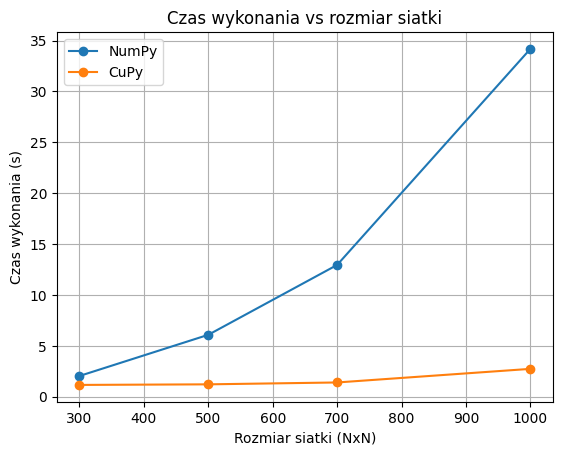

In [9]:
plt.plot(sizes, times_np, marker='o', label='NumPy')
plt.plot(sizes, times_cp, marker='o', label='CuPy')
plt.xlabel("Rozmiar siatki (NxN)")
plt.ylabel("Czas wykonania (s)")
plt.title("Czas wykonania vs rozmiar siatki")
plt.legend()
plt.grid()
plt.show()

### Krok 5 - Analiza - ilość iteracji

In [10]:
iterations = [200, 500, 1000, 1500]
N = 500

times_np_iter = []
times_cp_iter = []

for it in iterations:
    print(f"Iteracje: {it}")
    times_np_iter.append(gray_scott_numpy(N, it))
    times_cp_iter.append(gray_scott_cupy(N, it))

Iteracje: 200
Iteracje: 500
Iteracje: 1000
Iteracje: 1500


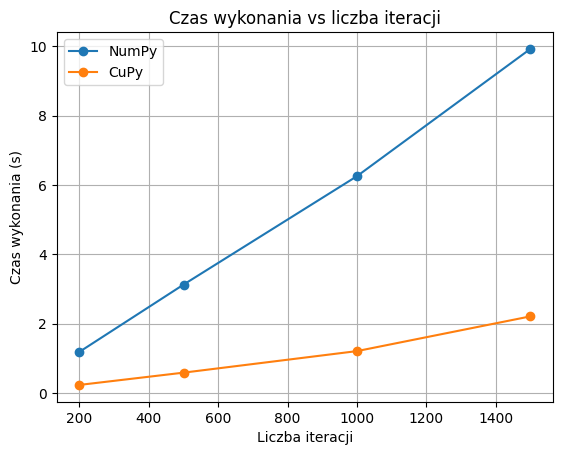

In [11]:
plt.plot(iterations, times_np_iter, marker='o', label='NumPy')
plt.plot(iterations, times_cp_iter, marker='o', label='CuPy')
plt.xlabel("Liczba iteracji")
plt.ylabel("Czas wykonania (s)")
plt.title("Czas wykonania vs liczba iteracji")
plt.legend()
plt.grid()
plt.show()

### Krok 6 - Analiza - przyspieszenie

In [12]:
speedup = [tn / tc for tn, tc in zip(times_np, times_cp)]

for N, s in zip(sizes, speedup):
    print(f"Przyspieszenie dla {N}x{N}: {s:.2f}x")

Przyspieszenie dla 300x300: 1.76x
Przyspieszenie dla 500x500: 5.02x
Przyspieszenie dla 700x700: 9.28x
Przyspieszenie dla 1000x1000: 12.51x


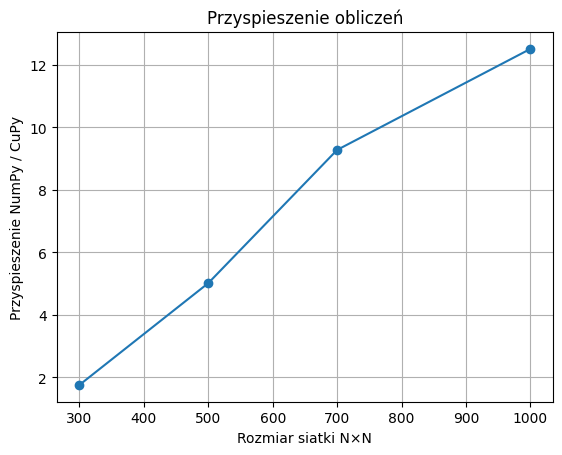

In [13]:
plt.plot(sizes, speedup, marker='o')
plt.xlabel("Rozmiar siatki N×N")
plt.ylabel("Przyspieszenie NumPy / CuPy")
plt.title("Przyspieszenie obliczeń")
plt.grid()
plt.show()